## Student Engagement Risk Classifier
### Objective: Predict student risk_level from LMS behavioural indicators

### Imported Libraries

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, classification_report, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay)
from sklearn.inspection import permutation_importance

try:
    from imblearn.over_sampling import SMOTE
    SMOTE_AVAILABLE = True
except ImportError:
    SMOTE_AVAILABLE = False
    

### 1: Load Dataset

In [4]:
print("=" * 60)
print("Student Engagement Risk Classifier")
print("=" * 60)

df = pd.read_csv('Teaching Quality and Student Engagement Dataset.csv')

print(f"\n[1] Dataset loaded: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Columns: {list(df.columns)}")

Student Engagement Risk Classifier

[1] Dataset loaded: 2100 rows, 15 columns
Columns: ['student_id', 'course_id', 'instructor_id', 'feedback_score', 'textual_review', 'attendance_rate', 'assignment_submission_rate', 'quiz_avg_score', 'exam_avg_score', 'lms_logins_past_month', 'avg_session_duration_minutes', 'forum_participation_count', 'video_completion_rate', 'instructor_response_time', 'risk_level']


### 2: Initial Inspection

In [5]:
print("\n[2] Missing values:")
print(df.isnull().sum())

print("\n[3] Risk level distribution:")
print(df['risk_level'].value_counts())


[2] Missing values:
student_id                      0
course_id                       0
instructor_id                   0
feedback_score                  0
textual_review                  0
attendance_rate                 0
assignment_submission_rate      0
quiz_avg_score                  0
exam_avg_score                  0
lms_logins_past_month           0
avg_session_duration_minutes    0
forum_participation_count       0
video_completion_rate           0
instructor_response_time        0
risk_level                      0
dtype: int64

[3] Risk level distribution:
risk_level
High      1319
Medium     608
Low        173
Name: count, dtype: int64


### 3: Preprocessing

In [6]:
# Drop non-predictive identifier columns
df.drop(columns=['student_id', 'course_id', 'instructor_id', 'textual_review'],
        inplace=True, errors='ignore')

# Encode target variable
le = LabelEncoder()
df['risk_level_encoded'] = le.fit_transform(df['risk_level'])
print(f"\n[4] Risk level encoding: {dict(zip(le.classes_, le.transform(le.classes_)))}")
TARGET = 'risk_level_encoded'
CLASS_NAMES = list(le.classes_)

# Drop original string target
df.drop(columns=['risk_level'], inplace=True)

# Define features
FEATURE_COLS = [c for c in df.columns if c != TARGET]

X = df[FEATURE_COLS]
y = df[TARGET]

# Impute missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=FEATURE_COLS)


[4] Risk level encoding: {'High': 0, 'Low': 1, 'Medium': 2}


### 4: Feature Engineering

In [7]:
# Composite engagement index: weighted sum of 3 key behavioural indicators
X_imputed['engagement_index'] = (
    0.4 * X_imputed['lms_logins_past_month'] / (X_imputed['lms_logins_past_month'].max() + 1e-9) +
    0.3 * X_imputed['assignment_submission_rate'] / 100 +
    0.3 * X_imputed['forum_participation_count'] / (X_imputed['forum_participation_count'].max() + 1e-9)
)

# Submission to login efficiency ratio
X_imputed['submission_login_ratio'] = (
    X_imputed['assignment_submission_rate'] / (X_imputed['lms_logins_past_month'] + 1e-9)
)

print("[5] Feature engineering complete: engagement_index, submission_login_ratio added")

[5] Feature engineering complete: engagement_index, submission_login_ratio added


### 5: Train / Test Split

In [8]:
X_train, X_test, y_train, y_test = train_test_split(
    X_imputed, y, test_size=0.2, random_state=42, stratify=y
)
print(f"\n[6] Train size: {X_train.shape[0]} | Test size: {X_test.shape[0]}")
print(f"Training class distribution:\n{pd.Series(y_train).value_counts().to_string()}")


[6] Train size: 1680 | Test size: 420
Training class distribution:
risk_level_encoded
0    1055
2     487
1     138


### 6: SMOTE for Class Imbalance (applied to training set only)

In [9]:
if SMOTE_AVAILABLE:
    smote = SMOTE(random_state=42)
    X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
    print(f"\n[7] After SMOTE — Training class distribution:")
    print(pd.Series(y_train_res).value_counts().to_string())
else:
    X_train_res, y_train_res = X_train.copy(), y_train.copy()
    print("\n[7] SMOTE skipped — using original training data")

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)


[7] After SMOTE — Training class distribution:
risk_level_encoded
0    1055
1    1055
2    1055


### 7: Model Training & Evaluation

In [10]:
print("\n[8] Training classification models...")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(
                               n_estimators=200, max_depth=None,
                               class_weight='balanced', random_state=42, n_jobs=-1),
    'SVM (RBF)':           SVC(kernel='rbf', C=1.0, gamma='scale',
                               probability=True, random_state=42)
}

results = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train_res)
    y_pred  = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled) if hasattr(model, 'predict_proba') else None

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    auc  = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted') if y_proba is not None else 'N/A'

    # 10-fold cross-validation
    cv = cross_val_score(model, X_train_scaled, y_train_res, cv=10, scoring='f1_weighted', n_jobs=-1)

    results[name] = {
        'Accuracy': round(acc, 4),
        'Precision': round(prec, 4),
        'Recall': round(rec, 4),
        'F1 (weighted)': round(f1, 4),
        'ROC-AUC': round(auc, 4) if isinstance(auc, float) else auc,
        'CV F1 mean': round(cv.mean(), 4),
        'CV F1 std':  round(cv.std(), 4)
    }

    print(f"\n  {name}:")
    print(f"    Accuracy      = {acc:.4f}")
    print(f"    Precision     = {prec:.4f}")
    print(f"    Recall        = {rec:.4f}")
    print(f"    F1 (weighted) = {f1:.4f}")
    print(f"    ROC-AUC       = {auc if isinstance(auc, str) else f'{auc:.4f}'}")
    print(f"    CV F1 (10-fold) = {cv.mean():.4f} ± {cv.std():.4f}")


[8] Training classification models...

  Logistic Regression:
    Accuracy      = 0.7167
    Precision     = 0.7491
    Recall        = 0.7167
    F1 (weighted) = 0.7263
    ROC-AUC       = 0.8451
    CV F1 (10-fold) = 0.8068 ± 0.0248

  Decision Tree:
    Accuracy      = 0.9952
    Precision     = 0.9953
    Recall        = 0.9952
    F1 (weighted) = 0.9952
    ROC-AUC       = 0.9967
    CV F1 (10-fold) = 0.9858 ± 0.0105

  Random Forest:
    Accuracy      = 0.9905
    Precision     = 0.9908
    Recall        = 0.9905
    F1 (weighted) = 0.9903
    ROC-AUC       = 0.9997
    CV F1 (10-fold) = 0.9915 ± 0.0119

  SVM (RBF):
    Accuracy      = 0.8738
    Precision     = 0.8754
    Recall        = 0.8738
    F1 (weighted) = 0.8745
    ROC-AUC       = 0.9638
    CV F1 (10-fold) = 0.9373 ± 0.0251


### 8: Confusion Matrices for all models

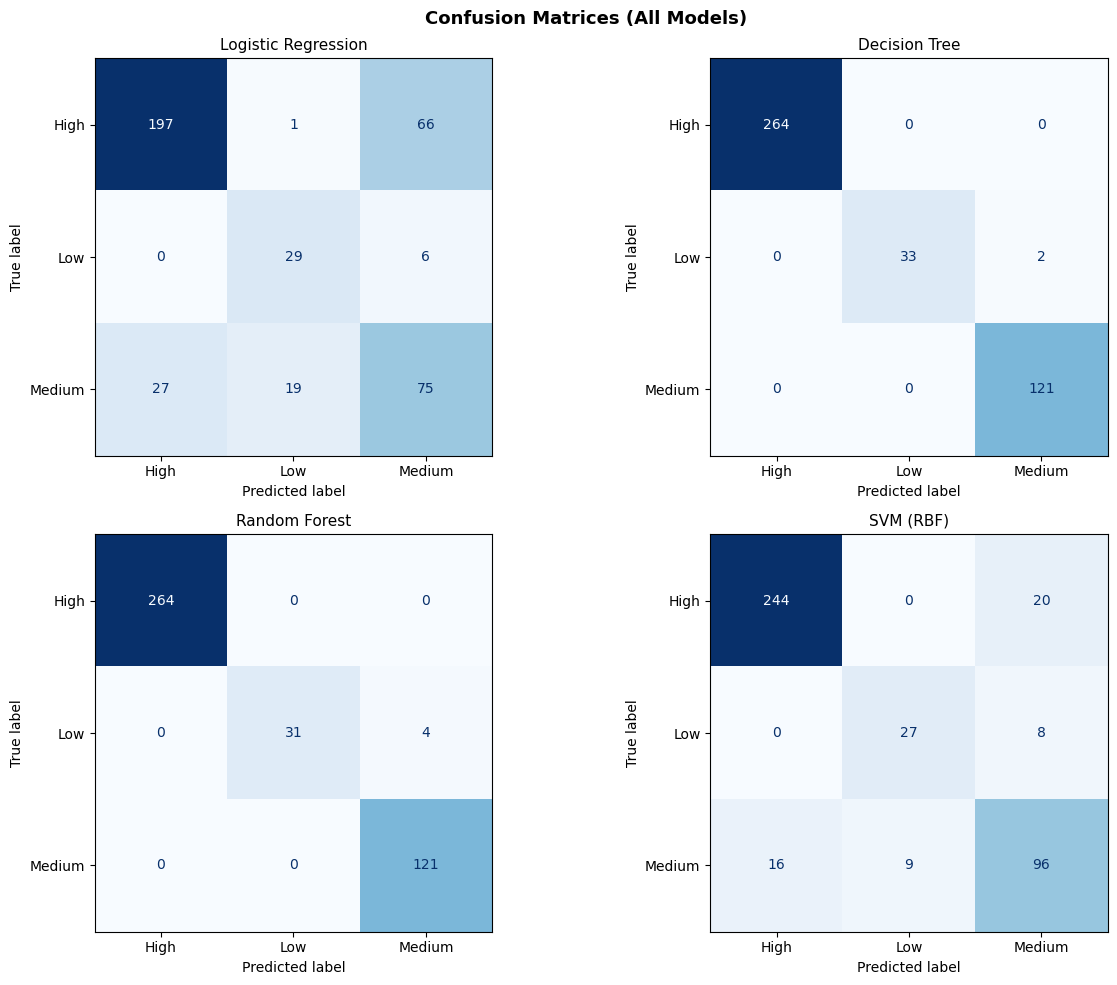

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
axes = axes.flatten()

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test_scaled)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}', fontsize=11)

plt.suptitle('Confusion Matrices (All Models)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()
plt.close()

### 9: Feature Importance (Random Forest)

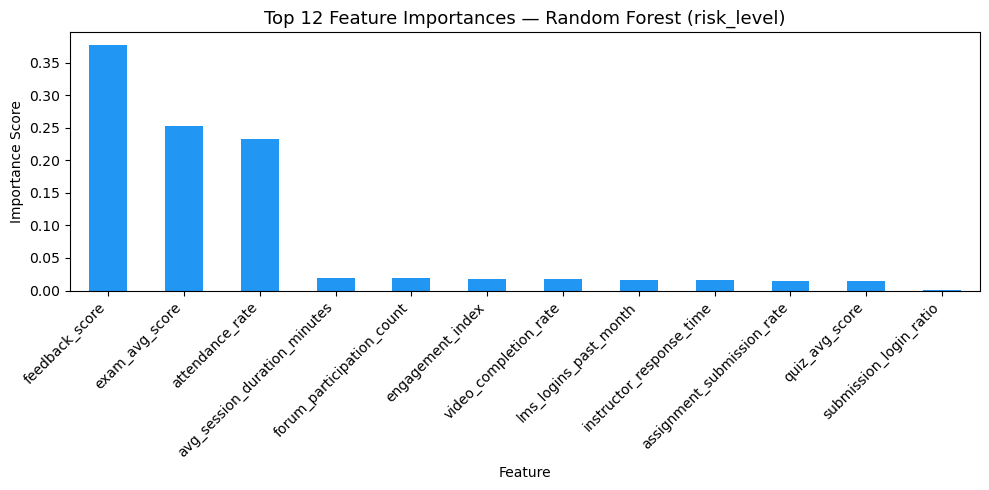


  Top features:
feedback_score                  0.377568
exam_avg_score                  0.252089
attendance_rate                 0.232492
avg_session_duration_minutes    0.020023
forum_participation_count       0.018725
engagement_index                0.018333
video_completion_rate           0.017716
lms_logins_past_month           0.016191
instructor_response_time        0.015494
assignment_submission_rate      0.014993
quiz_avg_score                  0.014934
submission_login_ratio          0.001443


In [12]:
rf_model = models['Random Forest']
feat_imp = pd.Series(
    rf_model.feature_importances_, index=X_imputed.columns
).sort_values(ascending=False).head(12)

plt.figure(figsize=(10, 5))
feat_imp.plot(kind='bar', color='#2196F3')
plt.title('Top 12 Feature Importances — Random Forest (risk_level)', fontsize=13)
plt.ylabel('Importance Score')
plt.xlabel('Feature')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()
plt.close()

print(f"\n  Top features:\n{feat_imp.to_string()}")

### 10: Model Comparison Bar Chart (F1 Score)

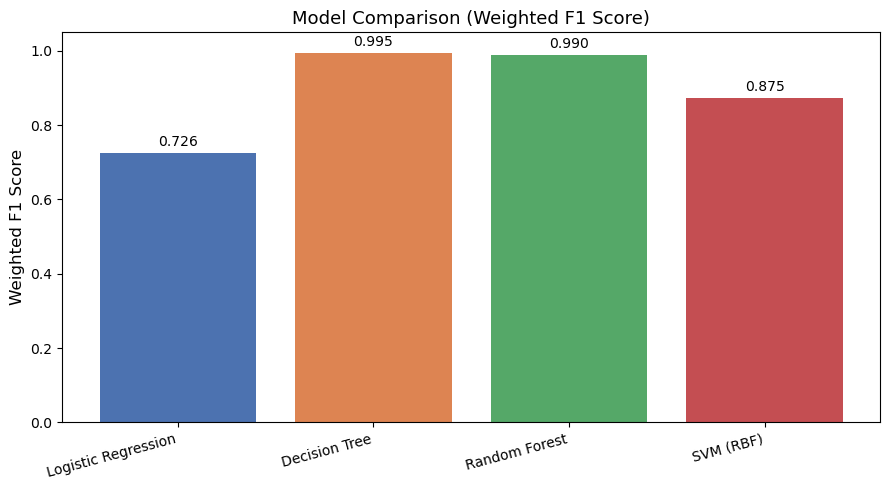

In [13]:
model_names = list(results.keys())
f1_vals = [results[m]['F1 (weighted)'] for m in model_names]

plt.figure(figsize=(9, 5))
bars = plt.bar(model_names, f1_vals, color=['#4C72B0','#DD8452','#55A868','#C44E52'])
plt.ylim(0, 1.05)
plt.ylabel('Weighted F1 Score', fontsize=12)
plt.title('Model Comparison (Weighted F1 Score)', fontsize=13)
plt.xticks(rotation=15, ha='right')
for bar, val in zip(bars, f1_vals):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
             f'{val:.3f}', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()
plt.close()

### 11: Full Classification Report (Best Model = Random Forest)

In [14]:
y_pred_rf = models['Random Forest'].predict(X_test_scaled)
print("\n[9] Full Classification Report — Random Forest:")
print(classification_report(y_test, y_pred_rf, target_names=CLASS_NAMES))


[9] Full Classification Report — Random Forest:
              precision    recall  f1-score   support

        High       1.00      1.00      1.00       264
         Low       1.00      0.89      0.94        35
      Medium       0.97      1.00      0.98       121

    accuracy                           0.99       420
   macro avg       0.99      0.96      0.97       420
weighted avg       0.99      0.99      0.99       420



### 12: Results Summary Table

In [15]:
print("\n" + "=" * 60)
print("RESULTS SUMMARY")
print("=" * 60)
results_df = pd.DataFrame(results).T
print(results_df.to_string())


RESULTS SUMMARY
                     Accuracy  Precision  Recall  F1 (weighted)  ROC-AUC  CV F1 mean  CV F1 std
Logistic Regression    0.7167     0.7491  0.7167         0.7263   0.8451      0.8068     0.0248
Decision Tree          0.9952     0.9953  0.9952         0.9952   0.9967      0.9858     0.0105
Random Forest          0.9905     0.9908  0.9905         0.9903   0.9997      0.9915     0.0119
SVM (RBF)              0.8738     0.8754  0.8738         0.8745   0.9638      0.9373     0.0251
